In [156]:
import torch
from torch import nn
import torchvision
import torchmetrics
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor

### Data load

In [157]:
train_dataset = torchvision.datasets.MNIST(root="data",
                                           train=True,
                                           transform=ToTensor(),
                                           target_transform=None,
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root="data",
                                           train=False,
                                           transform=ToTensor(),
                                           target_transform=None,
                                           download=True)

In [158]:
image, label = train_dataset[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [159]:
image.shape

torch.Size([1, 28, 28])

In [160]:
train_dataset.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [161]:
class_names = train_dataset.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

(-0.5, 27.5, 27.5, -0.5)

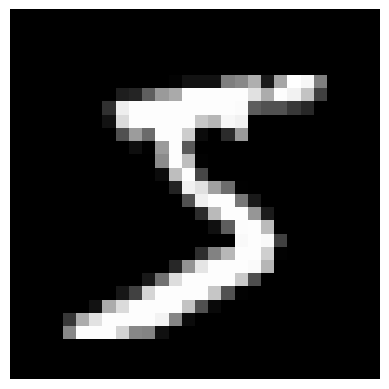

In [162]:
plt.imshow(image.squeeze(), cmap="gray")
plt.axis(False)

### Visualization

torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])
torch.Size([1, 28, 28])
torch.Size([28, 28])


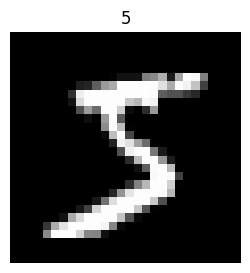

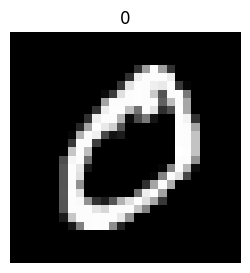

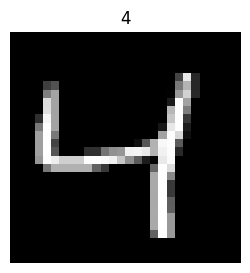

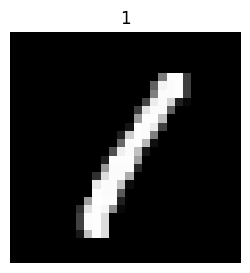

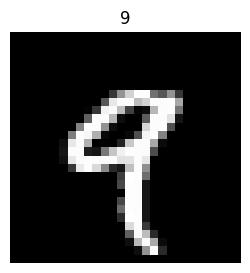

In [163]:
import matplotlib.pyplot as plt
for i in range(5):
  img = train_dataset[i][0]
  print(img.shape)
  img_squeeze = img.squeeze()
  print(img_squeeze.shape)
  label = train_dataset[i][1]
  plt.figure(figsize=(3, 3))
  plt.imshow(img_squeeze, cmap="gray")
  plt.title(label)
  plt.axis(False);

In [164]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset = train_dataset,
    batch_size = BATCH_SIZE,
    shuffle= True,
)
test_dataloader = DataLoader(
    dataset = test_dataset,
    batch_size = BATCH_SIZE,
    shuffle= True,
)
len(train_dataloader), len(test_dataloader)

(1875, 313)

In [165]:
device=torch.device("mps")
device

device(type='mps')

### Model Development

In [166]:
class MNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape, 
                      out_channels = hidden_units, 
                      kernel_size = 3, 
                      stride = 1, 
                      padding = 1),      
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, 
                      out_channels = hidden_units, 
                      kernel_size = 3, 
                      stride = 1, 
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)       
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units, 
                      kernel_size=3, 
                      stride=1, 
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units, 
                      kernel_size=3, 
                      stride=1, 
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )
    def forward(self, x:torch.tensor):
        x = self.conv_block_1(x)
        # print(f"Output shape of conv_block_1: {x.shape}")
        x = self.conv_block_2(x)
        # print(f"Output shape of conv_block_2: {x.shape}")
        x = self.classifier(x)
        return x

In [167]:
model_0 = MNISTModelV0(input_shape=1,
                    hidden_units=10,
                    output_shape=10).to(device)
model_0

MNISTModelV0(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### After flatten layer 

### Hidden Units * ? * ?

In [168]:
rand_image_tensor = torch.rand(size=(1, 28, 28)).unsqueeze(0).to(device)
rand_image_tensor.shape,
model_0(rand_image_tensor)

tensor([[-0.0102, -0.0380, -0.0231, -0.0059,  0.0891,  0.0261, -0.0741, -0.0002,
          0.0053,  0.0009]], device='mps:0', grad_fn=<LinearBackward0>)

In [169]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [170]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

### train step

In [171]:
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device = device):
            
    train_loss, train_acc = 0, 0
    model.train()

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss 
        train_acc += accuracy_fn(y_true=y, y_pred = y_pred.argmax(dim=1))

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    print(f"Training loss: {train_loss} | Training Accuracy: {train_acc}")

### test step

In [172]:
def test_step(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              accuracy_fn,
              device:torch.device = device):

    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            loss = loss_fn(y_pred, y)
            test_loss += loss

            test_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Training Loss: {test_loss} | Testing Loss: {test_acc}")

### Model Training

In [173]:
torch.manual_seed(42)

from timeit import default_timer as timer 
train_start_time = timer()

EPOCHS = 5

for epoch in tqdm(range(EPOCHS)):
    print(f"Epoch:")
    train_step(model=model_0,
               data_loader = train_dataloader,
               loss_fn = loss_fn,
               accuracy_fn= accuracy_fn,
               optimizer=optimizer,
               device=device)
    test_step(model=model_0,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)

train_end_time = timer()
total_train_time_model_0 = print_train_time(start=train_start_time, end=train_end_time, device=device)
    

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch:
Training loss: 0.33997535705566406 | Training Accuracy: 88.38833333333334


 20%|██        | 1/5 [00:09<00:36,  9.22s/it]

Training Loss: 0.08713648468255997 | Testing Loss: 97.4341054313099
Epoch:
Training loss: 0.07527434825897217 | Training Accuracy: 97.62833333333333


 40%|████      | 2/5 [00:18<00:27,  9.33s/it]

...

Training Loss: 0.05748376622796059 | Testing Loss: 98.31269968051119
Epoch:
Training loss: 0.04965590313076973 | Training Accuracy: 98.50333333333333


 80%|████████  | 4/5 [00:37<00:09,  9.38s/it]

Training Loss: 0.05057883262634277 | Testing Loss: 98.28274760383387
Epoch:
Training loss: 0.04325806349515915 | Training Accuracy: 98.66166666666666


100%|██████████| 5/5 [00:46<00:00,  9.34s/it]

Training Loss: 0.03806152567267418 | Testing Loss: 98.80191693290735
Train time on mps: 46.696 seconds


### Model Evaluation

In [174]:
def eval_model(model:torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn,
               device:torch.device = device):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred =model(X)

            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"Model Name: " : model.__class__.__name__,
            "Model Loss: " : loss.item(), 
            "Model Accuracy: " : acc}

In [200]:
model_0_results = eval_model(model = model_0,
           data_loader = test_dataloader,
           loss_fn = loss_fn,
           accuracy_fn = accuracy_fn,
           device = device)

### Make prediction

In [201]:
def make_predictions(model:torch.nn.Module, data:list, device:torch.device=device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:

            # Prepare sample 
            sample = torch.unsqueeze(sample, dim=0).to(device)  # Add an extra dimension and send sample to device

            # Forward pass (model output raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> preditction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())

    # return the pre_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [202]:
import random
random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_dataset), k=9):
    test_samples.append(sample)
    test_labels.append(label)

print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 2 (2 - two)


In [203]:
pred_probs = make_predictions(model = model_0, data=test_samples)
pred_probs

tensor([[2.6195e-08, 1.3651e-06, 9.9999e-01, 5.4637e-08, 7.0186e-15, 1.9654e-13,
         1.5893e-12, 5.7883e-08, 3.7576e-06, 8.2004e-10],
        [1.3467e-07, 9.9845e-01, 1.9298e-05, 3.3224e-07, 1.1235e-04, 7.9803e-05,
         1.4134e-05, 4.2538e-04, 5.5258e-04, 3.4198e-04],
        [1.3682e-05, 6.2283e-09, 9.9998e-01, 6.8137e-08, 2.3966e-11, 1.7930e-10,
         6.3595e-12, 2.7031e-07, 7.0662e-06, 3.7011e-09],
        [7.9784e-10, 2.8239e-08, 8.5035e-08, 6.3342e-08, 9.9605e-01, 2.2808e-07,
         3.1068e-09, 1.5721e-05, 3.0843e-06, 3.9290e-03],
        [2.1944e-05, 8.1409e-11, 4.8065e-10, 2.1141e-10, 5.2151e-06, 3.3964e-08,
         9.9997e-01, 1.3666e-09, 3.3215e-07, 7.2544e-09],
        [5.8617e-06, 1.2979e-09, 1.2780e-10, 1.6865e-10, 1.9415e-06, 3.2414e-07,
         9.9999e-01, 5.4191e-10, 6.2058e-06, 2.6865e-08],
        [1.9046e-13, 3.6768e-08, 2.4453e-09, 4.3286e-10, 9.9960e-01, 1.7744e-09,
         1.4544e-12, 2.9600e-07, 1.7534e-07, 3.9500e-04],
        [1.3959e-09, 3.9948

In [204]:
pred_class = pred_probs.argmax(dim=1)
pred_class

tensor([2, 1, 2, 4, 6, 6, 4, 9, 1])

In [205]:
pred_class, test_labels

(tensor([2, 1, 2, 4, 6, 6, 4, 9, 1]), [2, 1, 2, 4, 6, 6, 4, 9, 1])

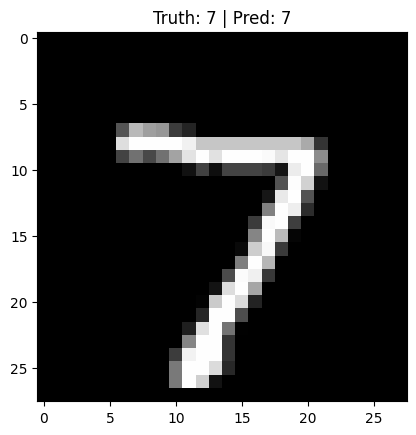

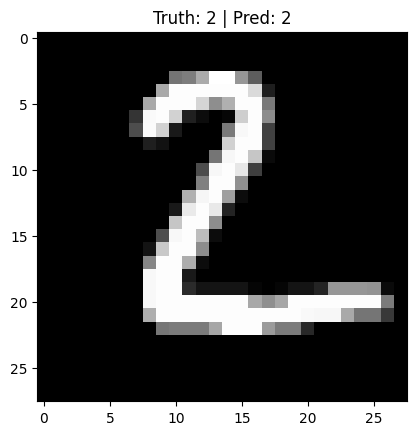

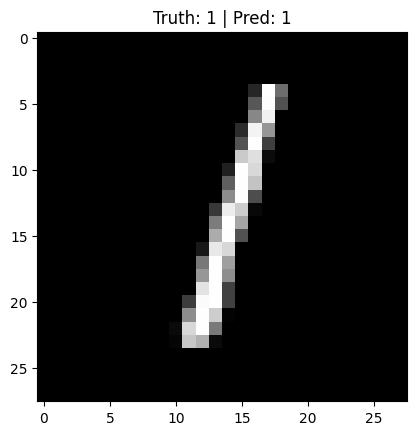

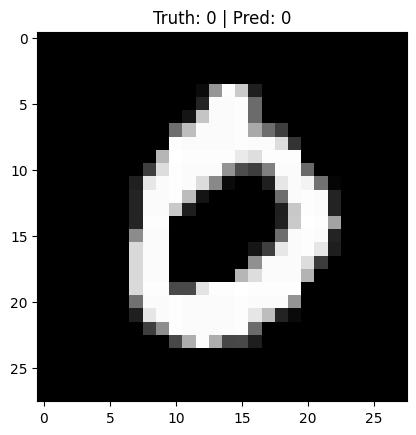

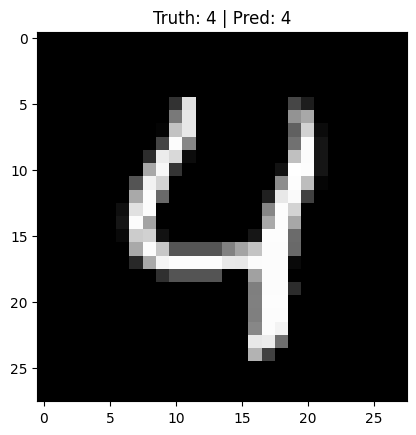

In [206]:
for i in range(5):
    img = test_dataset[i][0]
    label = test_dataset[i][1]
    
    model_pred_logits = model_0(img.unsqueeze(dim=0).to(device))
    model_pred_probs = torch.softmax(model_pred_logits, dim=1)
    model_pred_label = torch.argmax(model_pred_probs)

    # Plot the image and prediction
    plt.figure()
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Truth: {label} | Pred: {model_pred_label}")
    

### Model confusion metrix

In [207]:
# Make predictions across all test data
from tqdm.auto import tqdm
model_0.eval()
y_preds = []
with torch.inference_mode():
  for batch, (X, y) in tqdm(enumerate(test_dataloader)):
    # Make sure data on right device
    X, y = X.to(device), y.to(device)
    # Forward pass
    y_pred_logits = model_0(X)
    # Logits -> Pred probs -> Pred label
    y_pred_labels = torch.argmax(torch.softmax(y_pred_logits, dim=1), dim=1)
    # Append the labels to the preds list
    y_preds.append(y_pred_labels)
  y_preds=torch.cat(y_preds).cpu()

len(y_preds)

313it [00:00, 462.84it/s]


10000

In [208]:
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1] >= 19), "mlxtend verison should be 0.19.0 or higher"

except:
    !pip install -q torchmetrics -U mlxtend
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.22.0
mlxtend version: 0.22.0


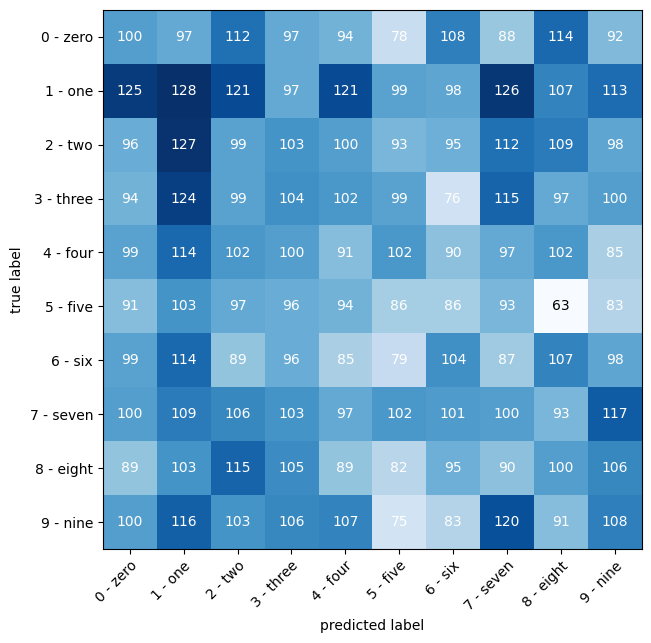

In [209]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion matrix 
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_preds,
                         target=test_dataset.targets)

# Plot the confusion matrix
fix, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

In [210]:
random_tensor = torch.rand([1, 3, 64, 64])
random_tensor.shape

torch.Size([1, 3, 64, 64])

In [211]:
conv_layer =  nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=2, padding=1)

print(f"Random tensor original shape: {random_tensor.shape}")
random_tensor_through_conv_layer = conv_layer(random_tensor)
print(f"Random tensor through conv layer shape: {random_tensor_through_conv_layer.shape}")

Random tensor original shape: torch.Size([1, 3, 64, 64])
Random tensor through conv layer shape: torch.Size([1, 64, 32, 32])


In [212]:
from pathlib import Path

# Create models directory (if it doesn't already exist), see: https://docs.python.org/3/library/pathlib.html#pathlib.Path.mkdir
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                 exist_ok=True # if models directory already exists, don't error
)

# Create model save path
MODEL_NAME = "03_pytorch_computer_vision_exercises_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision_exercises_model_2.pth


In [213]:
# Create a new instance of FashionMNISTModelV2 (the same class as our saved state_dict())
# Note: loading model will error if the shapes here aren't the same as the saved version
loaded_model_0 = MNISTModelV0(input_shape=1, 
                              hidden_units=10, # try changing this to 128 and seeing what happens 
                              output_shape=10) 

# Load in the saved state_dict()
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Send model to GPU
loaded_model_0 = loaded_model_0.to(device)

In [214]:
# Evaluate loaded model
torch.manual_seed(42)

loaded_model_0_results = eval_model(
    model=loaded_model_0,
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    accuracy_fn=accuracy_fn
)

loaded_model_0_results

{'Model Name: ': 'MNISTModelV0',
 'Model Loss: ': 0.03808026388287544,
 'Model Accuracy: ': 98.80191693290735}

In [217]:
model_0_results

{'Model Name: ': 'MNISTModelV0',
 'Model Loss: ': 0.03807110711932182,
 'Model Accuracy: ': 98.80191693290735}

In [ ]:
# Check to see if results are close to each other (if they are very far away, there may be an error)
torch.isclose(torch.tensor(model_0_results["Model Loss"]), 
              torch.tensor(loaded_model_0_results["Model Loss"]),
              atol=1e-08, # absolute tolerance
              rtol=0.0001) # relative tolerance